# CliffWalking Q-Learning

## 实验目标

本实验使用 `Q-Learning` 求解 CliffWalking，目标是展示 off-policy 时序差分学习如何在带有明确高风险区域的环境里，逐步学出一条高回报但更贴近悬崖边缘的路径。这个实验的重点不是只让智能体到达终点，而是让读者看到：`Q-Learning` 与 `SARSA` 在同一环境中为什么常常会呈现不同的风险偏好。


## 为什么这里选择 Q-Learning

CliffWalking 是解释 `Q-Learning` 的经典环境之一。和 `SARSA` 相比，`Q-Learning` 在更新时使用的是“下一状态下最优动作的估计价值”，而不是当前实际执行动作的价值，因此它学习的是更偏向最优贪心策略的目标。

放在这个环境里，这种 off-policy 特性通常会带来几个典型现象：

- 更容易学出贴近悬崖的最短路径
- 训练时虽然仍然在探索，但更新目标本身更激进
- 最终贪心策略往往比 `SARSA` 更追求最短步数，而不是更保守的安全边界

因此，CliffWalking 很适合用来讲清楚 `Q-Learning` 的方法特征，而不只是把它当成一张会更新的 Q 表。


## 收敛判断方式

这个 notebook 不会空泛地宣称“已经学会”，而是通过几组具体信号判断训练是否进入稳定阶段：

- 滚动平均回报是否持续改善
- 滚动成功率是否明显高于随机基线
- 滚动掉崖率是否逐步下降
- `epsilon` 是否按预期从高探索逐步衰减到较低水平
- 最终贪心策略图是否形成一条连贯的到终点路径

只有这些信号同时成立，才说明 `Q-Learning` 不只是偶尔成功，而是真的学到了稳定的状态-动作价值结构。


## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不使用并行环境

原因是本实验是典型表格强化学习任务，更新对象只是一张 Q 表，没有必要引入 GPU 或并行采样。这里的重点是把价值更新逻辑和策略形状讲清楚，而不是做吞吐优化。


In [1]:
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [2]:
ENV_ID = "CliffWalking-v1"
NUM_EPISODES = 30000
MAX_STEPS = 200
LEARNING_RATE = 0.1
GAMMA = 1.0
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.9998
ROLLING_WINDOW = 200
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)
num_states = env.observation_space.n
num_actions = env.action_space.n
q_table = np.zeros((num_states, num_actions), dtype=np.float32)


## 参数选择说明

这里的参数是按 CliffWalking 这种小型离散风险环境来配的，重点是让策略形状足够稳定可观察：

- `NUM_EPISODES = 30000`：给表格方法足够训练预算，避免只学到粗糙路径偏好
- `LEARNING_RATE = 0.1`：作为表格方法的稳妥起点，既能更新，也不至于让 Q 值震荡过猛
- `GAMMA = 1.0`：CliffWalking 更适合累计完整路径代价，因此不刻意折损长期回报
- `EPSILON_START = 1.0`：训练初期充分探索
- `EPSILON_END = 0.05`：训练后期仍保留少量探索，避免过早僵化
- `EPSILON_DECAY = 0.9998`：让探索衰减更慢，给高风险边界区域更多被反复修正的机会
- `ROLLING_WINDOW = 200`：平滑训练曲线，便于观察趋势

如果训练后策略仍明显不稳，优先调整的方向通常是：

- 增加训练回合数
- 放慢 epsilon 衰减
- 微调学习率


In [3]:
def epsilon_greedy_action(q_values, state, epsilon, action_space):
    if np.random.random() < epsilon:
        return action_space.sample()
    return int(np.argmax(q_values[state]))


In [4]:
epsilon = EPSILON_START
episode_rewards = []
episode_successes = []
cliff_falls = []
epsilons = []
episode_lengths = []

for episode in tqdm(range(NUM_EPISODES), desc="Q-Learning episodes"):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    fell = 0

    for step in range(MAX_STEPS):
        action = epsilon_greedy_action(q_table, state, epsilon, env.action_space)
        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if reward <= -100:
            fell = 1

        best_next_q = np.max(q_table[next_state])
        td_target = reward + GAMMA * best_next_q * (1 - int(terminated or truncated))
        td_error = td_target - q_table[state, action]
        q_table[state, action] += LEARNING_RATE * td_error

        state = next_state

        if terminated or truncated:
            episode_lengths.append(step + 1)
            episode_success = int(terminated)
            break
    else:
        episode_lengths.append(MAX_STEPS)
        episode_success = 0

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
    episode_rewards.append(total_reward)
    episode_successes.append(episode_success)
    cliff_falls.append(fell)
    epsilons.append(epsilon)

env.close()


Q-Learning episodes:   0%|          | 0/30000 [00:00<?, ?it/s]

In [5]:
reward_series = pd.Series(episode_rewards)
success_series = pd.Series(episode_successes)
fall_series = pd.Series(cliff_falls)
epsilon_series = pd.Series(epsilons)

rolling_reward = reward_series.rolling(ROLLING_WINDOW).mean()
rolling_success = success_series.rolling(ROLLING_WINDOW).mean()
rolling_fall = fall_series.rolling(ROLLING_WINDOW).mean()


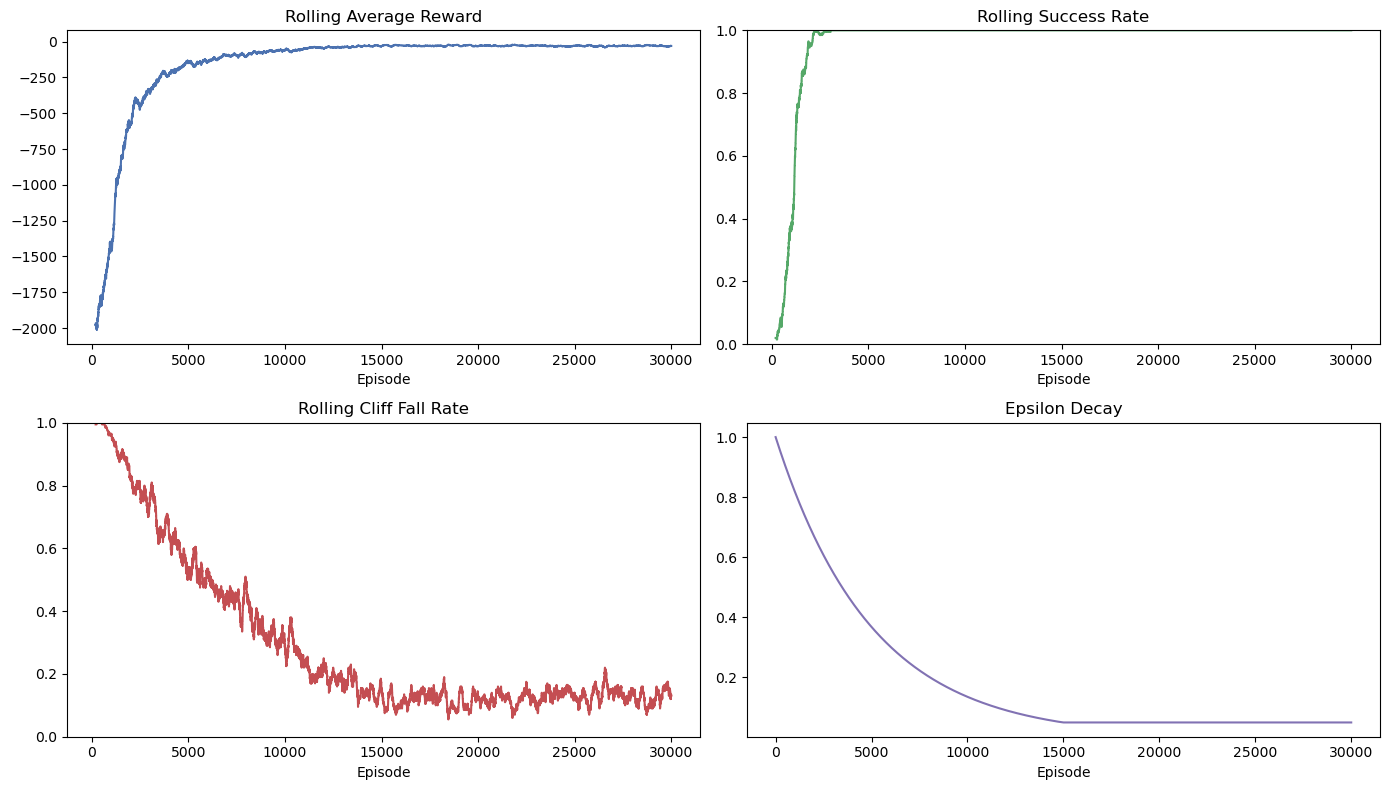

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(rolling_reward, color="#4c72b0")
axes[0, 0].set_title("Rolling Average Reward")
axes[0, 0].set_xlabel("Episode")

axes[0, 1].plot(rolling_success, color="#55a868")
axes[0, 1].set_title("Rolling Success Rate")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylim(0, 1)

axes[1, 0].plot(rolling_fall, color="#c44e52")
axes[1, 0].set_title("Rolling Cliff Fall Rate")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(epsilon_series, color="#8172b3")
axes[1, 1].set_title("Epsilon Decay")
axes[1, 1].set_xlabel("Episode")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "q_learning_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


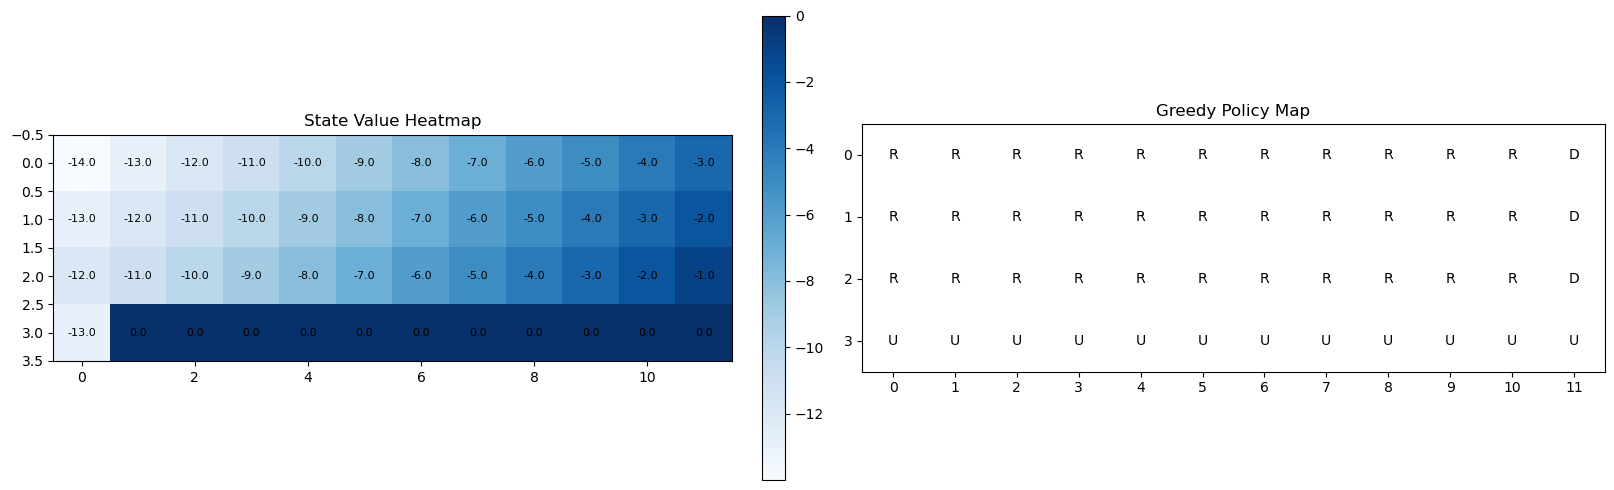

In [7]:
action_symbols = np.array(["U", "R", "D", "L"])
best_actions = action_symbols[np.argmax(q_table, axis=1)].reshape(4, 12)
state_values = np.max(q_table, axis=1).reshape(4, 12)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(state_values, cmap="Blues")
axes[0].set_title("State Value Heatmap")
for i in range(4):
    for j in range(12):
        axes[0].text(j, i, f"{state_values[i, j]:.1f}", ha="center", va="center", color="black", fontsize=8)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(np.zeros((4, 12)), cmap="Greys", vmin=0, vmax=1)
axes[1].set_title("Greedy Policy Map")
for i in range(4):
    for j in range(12):
        axes[1].text(j, i, best_actions[i, j], ha="center", va="center", color="black", fontsize=10)
axes[1].set_xticks(range(12))
axes[1].set_yticks(range(4))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "q_learning_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
def greedy_rollout(q_values, env_id, max_steps=200, seed=SEED + 100000):
    eval_env = gym.make(env_id)
    state, info = eval_env.reset(seed=seed)
    visited_states = [state]
    total_reward = 0.0
    fell = 0

    for step in range(max_steps):
        action = int(np.argmax(q_values[state]))
        next_state, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        if reward <= -100:
            fell = 1
        state = next_state
        visited_states.append(state)
        if terminated or truncated:
            eval_env.close()
            return {
                "greedy_return": total_reward,
                "greedy_steps": step + 1,
                "greedy_success": int(terminated),
                "greedy_cliff_fall": fell,
                "visited_states": visited_states,
            }

    eval_env.close()
    return {
        "greedy_return": total_reward,
        "greedy_steps": max_steps,
        "greedy_success": 0,
        "greedy_cliff_fall": fell,
        "visited_states": visited_states,
    }


greedy_eval = greedy_rollout(q_table, ENV_ID, max_steps=MAX_STEPS)
greedy_eval


{'greedy_return': -13.0,
 'greedy_steps': 13,
 'greedy_success': 1,
 'greedy_cliff_fall': 0,
 'visited_states': [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]}

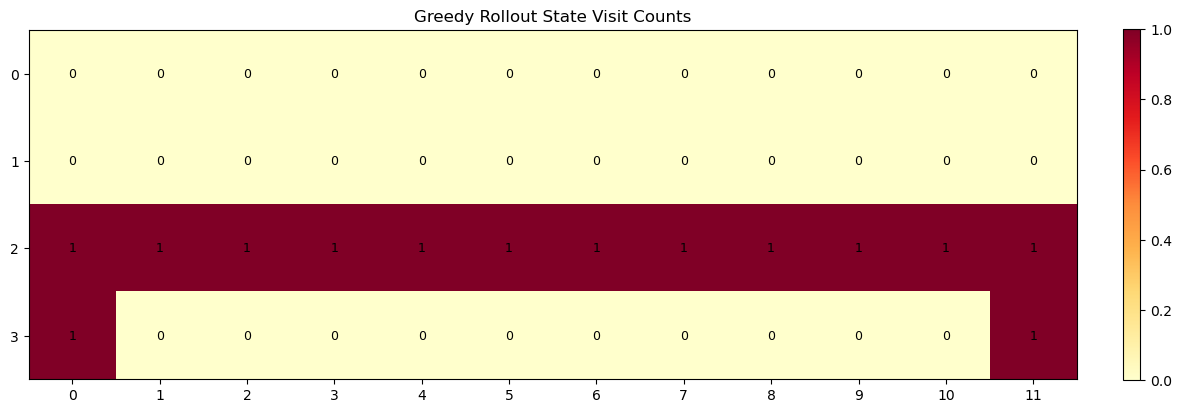

In [9]:
path_counts = np.zeros(num_states, dtype=int)
for state in greedy_eval["visited_states"]:
    path_counts[state] += 1
path_grid = path_counts.reshape(4, 12)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(path_grid, cmap="YlOrRd")
ax.set_title("Greedy Rollout State Visit Counts")
for i in range(4):
    for j in range(12):
        ax.text(j, i, str(path_grid[i, j]), ha="center", va="center", color="black", fontsize=9)
ax.set_xticks(range(12))
ax.set_yticks(range(4))
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "q_learning_greedy_rollout.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:
metrics = pd.DataFrame(
    {
        "metric": [
            "overall_success_rate",
            "average_reward",
            "average_episode_length",
            "cliff_fall_rate",
            "final_epsilon",
            "greedy_eval_return",
            "greedy_eval_steps",
            "greedy_eval_success",
            "greedy_eval_cliff_fall",
        ],
        "value": [
            float(np.mean(episode_successes)),
            float(np.mean(episode_rewards)),
            float(np.mean(episode_lengths)),
            float(np.mean(cliff_falls)),
            float(epsilon),
            float(greedy_eval["greedy_return"]),
            float(greedy_eval["greedy_steps"]),
            float(greedy_eval["greedy_success"]),
            float(greedy_eval["greedy_cliff_fall"]),
        ],
    }
)
metrics


,metric,value
0,overall_success_rate,0.965733
1,average_reward,-149.506100
2,average_episode_length,28.191500
3,cliff_fall_rate,0.294367
4,final_epsilon,0.050000
5,greedy_eval_return,-13.000000
6,greedy_eval_steps,13.000000
7,greedy_eval_success,1.000000
8,greedy_eval_cliff_fall,0.000000


In [11]:
metrics.to_csv(RESULTS_DIR / "q_learning_metrics.csv", index=False)
pd.DataFrame(q_table).to_csv(RESULTS_DIR / "q_learning_q_table.csv", index=False)
pd.DataFrame(
    {
        "step_index": list(range(len(greedy_eval["visited_states"]))),
        "state": greedy_eval["visited_states"],
    }
).to_csv(RESULTS_DIR / "q_learning_greedy_rollout_states.csv", index=False)

print(f"Overall success rate: {np.mean(episode_successes):.4f}")
print(f"Average reward: {np.mean(episode_rewards):.2f}")
print(f"Average episode length: {np.mean(episode_lengths):.2f}")
print(f"Cliff fall rate: {np.mean(cliff_falls):.4f}")
print(f"Final epsilon: {epsilon:.4f}")
print(f"Greedy eval return: {greedy_eval['greedy_return']:.2f}")
print(f"Greedy eval steps: {greedy_eval['greedy_steps']}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Overall success rate: 0.9657
Average reward: -149.51
Average episode length: 28.19
Cliff fall rate: 0.2944
Final epsilon: 0.0500
Greedy eval return: -13.00
Greedy eval steps: 13
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/04-cliffwalking-q-learning/results


## 结果解读

这个实验最重要的不只是“有没有到终点”，而是最终策略的风险形状。重点观察：

- 平均回报是否逐步改善
- 掉崖率是否逐步下降
- 最终贪心策略是否形成一条连贯的到终点路径
- 这条路径是否更贴近悬崖边界，而不是像 `SARSA` 那样明显保守

如果这些现象都成立，就说明 `Q-Learning` 正在逼近一条高回报的最短路径。这正是它在 CliffWalking 里最典型、也最有教学价值的地方：它往往学得更激进，路径更短，但风险容忍度也更高。
